# Introduction to Singular Value Decomposition (SVD)
In one of our lectures, we discussed the concept of <i>matrix factorization</i> methods - where we decompose a matrix into two or more simpler matrices. This is an example of <i>dimensionality reduction</i>, and these simpler matrices allow us to capture the underlying structure and relationships within the data.

Previously, we have discussed Principal Component Analysis (PCA) and Nonnegative Matrix Factorization (NMF) as matrix factorization methods. However, for this blog post we will be looking at: <i>Singular Value Decomposition</i> (SVD). A SVD of a real matrix $A \in \mathbb{R}^{m \times n}$ is:<br><br>
$$
A = UDV^{T}
$$
In this decomposition:
<ol>
    <li> D: $D \in \mathbb{R}^{m \times n} \rightarrow$ whose diagonal contains singular values $\sigma_i$ of $A$. The singular values quantify the importance of each singular vector in capturing the underlying structure and variations in the data. Larger singular values indicate more significant contributions to the data's variation, while smaller singular values represent less significant contributions.
    <li> U: $U \in \mathbb{R}^{m \times m} \rightarrow \text{Orthogonal Matrix}$ 
    <li> V: $V \in \mathbb{R}^{n \times n} \rightarrow \text{Orthogonal Matrix}$
</ol>

# Matrix Approximation using SVD
In this section of the blog post, we aim to:
<ol>
    <li> Get acquainted with <i>numpy's</i> implementation of SVD
    <li> Develop an appreciation of how SVD allows us to approximate a matrix $A$ using much smaller representations of matrices
</ol>

#### <font color="green">Getting Acquainted with <i>Numpy's</i> Implementation of SVD</font>
Before we decompose a matrix $A$ using SVD, we need to construct a sample matrix $A$:

In [8]:
from matplotlib import pyplot as plt
import numpy as np
np.random.seed(12345)

a1 = np.random.randint(1, 3, (5, 4))
a2 = np.random.randint(1, 3, (4, 8))

#constructing our sample matrix A
A = a1@a2 + 0.1*np.random.rand(5, 8)

Now, we can go ahead and visualize this matrix: 

In [30]:
A

array([[11.09940146, 11.06768737, 12.07908225, 14.01709143, 14.00268493,
        11.08003702, 10.09037225, 11.00246762],
       [ 7.04917473,  8.05262552,  9.0596366 , 10.00519575, 10.08950895,
         8.07282662,  7.081835  ,  8.05002228],
       [11.08101894, 10.00959685, 12.021895  , 14.02587191, 14.04681058,
        10.04593732, 11.07095098, 10.0178053 ],
       [ 9.05314499, 10.01677422, 11.07688139, 12.09281705, 12.06094937,
         9.01501835,  8.04896267, 10.0377345 ],
       [10.08486014, 11.09110972, 13.03838487, 14.03154959, 14.05683942,
        10.0187818 , 10.01258415, 11.06875958]])

With matrices, it is often of utility to visualize them as an image to get an understanding of the underlying pattern:

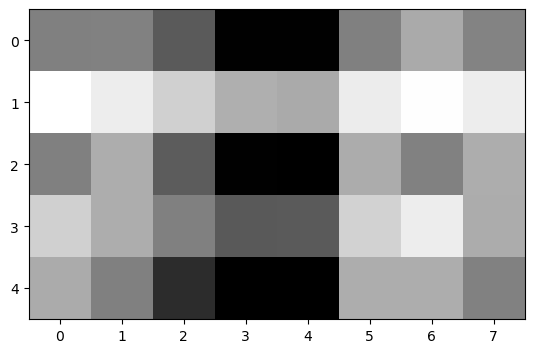

In [11]:
plt.imshow(A, cmap = "Greys")
a = plt.gca().axis("on")

Now that we have our matrix $A$, we can use <i>numpy's</i> implementation of SVD, to get $U$, $V$, and <i>sigma</i> which has been discussed above. The only difference is that we get <i>sigma</i> and not $D$. This means that we get a numpy array of the singular values of $A$, but we have to construct a diagonal matrix - $D$ - ourselves, where the diagonals contain the singular values of $A$. We can wrap up all of these functionalities in a single function:

In [19]:
def getValues():
    U, sigma, V = np.linalg.svd(A)
    D = diagonalize(sigma)
    return U, D, V

def diagonalize(sigma):
    # creating the D matrix in the SVD 
    # here the matrix of 0s will have the same shape as A
    D = np.zeros_like(A, dtype=float)
    # putting the singular values along the diagonal of D
    D[:min(A.shape),:min(A.shape)] = np.diag(sigma)  
    return D

U, D, V = getValues()

Now, let us try to reconstruct $A$ using the decomposed matrices as displayed in the formula above and compare it to the original $A$:

In [22]:
U @ D @ V

array([[11.09940146, 11.06768737, 12.07908225, 14.01709143, 14.00268493,
        11.08003702, 10.09037225, 11.00246762],
       [ 7.04917473,  8.05262552,  9.0596366 , 10.00519575, 10.08950895,
         8.07282662,  7.081835  ,  8.05002228],
       [11.08101894, 10.00959685, 12.021895  , 14.02587191, 14.04681058,
        10.04593732, 11.07095098, 10.0178053 ],
       [ 9.05314499, 10.01677422, 11.07688139, 12.09281705, 12.06094937,
         9.01501835,  8.04896267, 10.0377345 ],
       [10.08486014, 11.09110972, 13.03838487, 14.03154959, 14.05683942,
        10.0187818 , 10.01258415, 11.06875958]])

In [23]:
A

array([[11.09940146, 11.06768737, 12.07908225, 14.01709143, 14.00268493,
        11.08003702, 10.09037225, 11.00246762],
       [ 7.04917473,  8.05262552,  9.0596366 , 10.00519575, 10.08950895,
         8.07282662,  7.081835  ,  8.05002228],
       [11.08101894, 10.00959685, 12.021895  , 14.02587191, 14.04681058,
        10.04593732, 11.07095098, 10.0178053 ],
       [ 9.05314499, 10.01677422, 11.07688139, 12.09281705, 12.06094937,
         9.01501835,  8.04896267, 10.0377345 ],
       [10.08486014, 11.09110972, 13.03838487, 14.03154959, 14.05683942,
        10.0187818 , 10.01258415, 11.06875958]])

They are the same!

#### <font color = "green">Approximating $A$ using Smaller Matrices</font>
One of the main reasons why SVD is so useful is because we can get a pretty good approximation of the matrix $A$ by choosing a smaller subset of these decomposed matrices: $U$, $D$, and $V$. For instance, in our original situation:<br><br>
$$
A = UDV^{T} = \{m \times m\} \times \{m \times n\} \times \{n \times n\} = \{m \times n\}
$$
<br>However, we can choose a subset say $k$ = 3, where we will only:
<ul>
    <li> Pick the first $k$ columns of U
    <li> Pick the top $k$ singular values of D
    <li> Pick the first $k$ rows of V
</ul>

Which gives us:<br><br>
$$
A = UDV^{T} = \{m \times k\} \times \{k \times k\} \times \{k \times n\} = \{m \times n\}
$$
<br>Therefore, we can get a $m \times n$ approximation of $A$ using a smaller subset of these decomposed matrices. The way this works is that in SVD, the obtained singular values are present in decreasing order of "importance". This means that the first singular value is typically the most important in terms of capturing the primary patterns, structures, and variations of the data, and this "importance" keeps on decreasing as we go down. Therefore, depending on our value of $k$, we can get a pretty good approximation of the original matrix using a relatively smaller subset of the decomposed matrices. To see this in practice, let us create a function that will allow us to visualize our: original matrix $A$ and the reconstructed matrix $A$ with a smaller subset of the decomposed matrices, as images. This will allow us to get an appreciation of how similar the reconstructed matrix $A$ is to the original one, while saving us a lot of space because we used a smaller subset of the matrices:

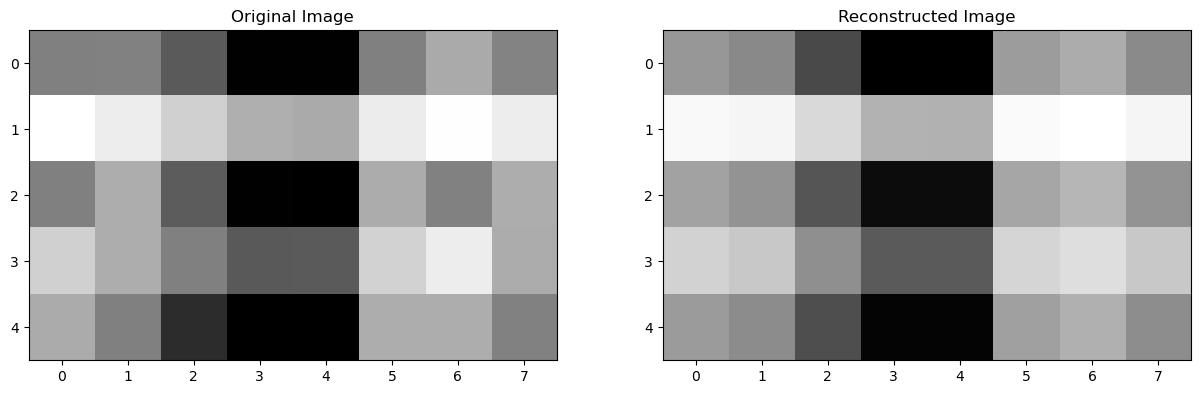

In [36]:
def compareImages(A, A_):
    fig, axarr = plt.subplots(1, 2, figsize = (15, 5))
    
    axarr[0].imshow(A, cmap = "Greys")
    axarr[0].axis("on")
    axarr[0].set(title = "Original Image")
    
    axarr[1].imshow(A_, cmap = "Greys")
    axarr[1].axis("on")
    axarr[1].set(title = "Reconstructed Image")

#creating subsets of the decomposed matrices
k = 1
U_ = U[:,:k]
D_ = D[:k, :k]
V_ = V[:k, :]
A_ = U_ @ D_ @ V_

# visualizing the original and reconstructed matrix A (images)
compareImages(A, A_)

Therefore, we can see that our <i>reconstructed image</i> is pretty much the same as the original image, and we have reduced the dimensions of our problem from: 
<ol>
    <li> $A_\text{original} = UDV^{T} = \{5 \times 5\} \times \{5 \times 8\} \times \{8 \times 8\} = \{5 \times 8\}$, to 
    <li> $A_\text{reconstructed} = U_{\text{k}}D_{\text{k}}V_{\text{k}}^{T} = \{5 \times 1\} \times \{1 \times 1\} \times \{1 \times 8\} = \{5 \times 8\}$
</ol>

# Image Compression using Matrix Approximation
Now that we have understood how using SVD, we can get a fairly good approximation of the matrix $A$ using a much smaller subset of the decomposed matrices, we can go ahead and apply to this to <i>image compression</i>. In simple words, what we are trying to do is: 
<ol>
    <li>Represent an image as a matrix,
    <li>Decompose the matrix using SVD,
    <li>Use a smaller subset of these decomposed matrices to reconstruct the original image (matrix)
</ol>  

For the purpose of this experiment, the chosen image is:
<center>
    <figure>
      <img src ="spongebob.jpg" height=500 width=800 caption="Mr. Squarepants"/>
      <figcaption>SpongeBob SquarePants</figcaption>
    </figure>
</center>

Now, let us get started:

In [39]:
import PIL
import urllib

#function to read an image and save it as a numpy array 
def read_image(url):
    return np.array(PIL.Image.open(urllib.request.urlopen(url)))

url = "https://i.pinimg.com/originals/1f/f9/68/1ff9682f61e99f217bb67a61f02ecb56.jpg"

img = read_image(url)

np.shape(img)

(1200, 1920, 3)

Therefore, we can see that our image is stored as a numpy object of shape: $1200 \times 1920 \times 3$, this means that there are $1200$ rows, $1920$ columns, and the $3$ is representative of the RGB channels - since at each pixel there is a numerical value for all red, green, and blue. To simplify our task of image compression using SVD, we want to deal with a 2-Dimensional matrix. To do this, we can convert this image to <i>greyscale</i> in which case it will have dimensions: $1200 \times 1920$ - $1200$ rows, $1920$ columns, and each value will range from $0$ to $255$. Where, $0$ = Black, and $255$ = White. Converting our image to <i>greyscale</i>:

In [41]:
def to_greyscale(image):
    return 1 - np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])

grey_img = to_greyscale(img)

np.shape(grey_img)

(1200, 1920)

As mentioned, the image is now a $1200 \times 1920$ matrix. Now, let us visualize the original and greyscale image side-by-side:

[Text(0.5, 1.0, 'Greyscale Image')]

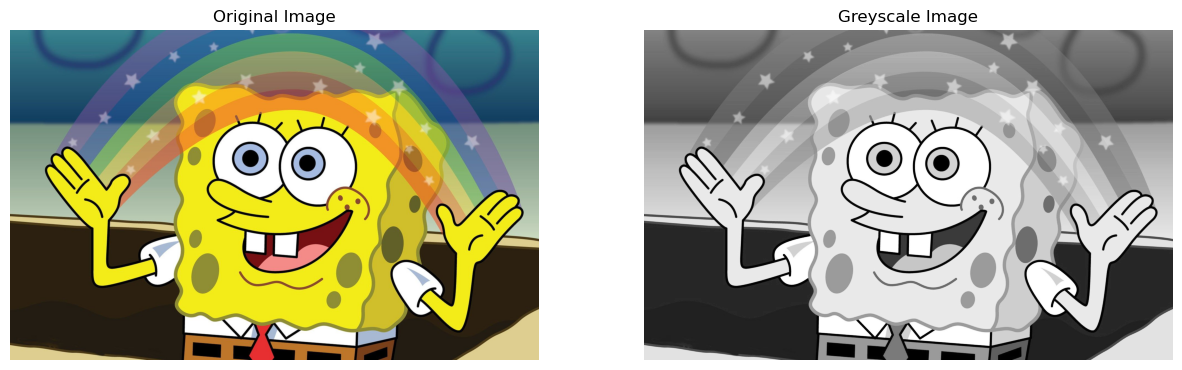

In [43]:
fig, axarr = plt.subplots(1, 2, figsize = (15, 5))

axarr[0].imshow(img)
axarr[0].axis("off")
axarr[0].set(title = "Original Image")

axarr[1].imshow(grey_img, cmap = "Greys")
axarr[1].axis("off")
axarr[1].set(title = "Greyscale Image")